In [1]:
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

RANDOM_STATE = 42
TARGET_COL = "Class"
TEST_SIZE = 0.2

In [2]:
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Ensure the directory exists
DATA_RAW.mkdir(parents=True, exist_ok=True)
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Check if the file exists before reading
csv_file = DATA_RAW / "creditcard.csv"
if csv_file.exists():
    df = pd.read_csv(csv_file, low_memory=False)  # Suppress DtypeWarning
    df.head(10)
else:
    print(f"File not found: {csv_file}")


In [3]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [7]:
train_idx = pd.read_csv(SPLITS_DIR / "X_train.csv", header=None).squeeze()

X_train = X.loc[train_idx].copy()
y_train = y.loc[train_idx].copy()

In [10]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
import json

# Constants
SECONDS_IN_DAY = 86400
USE_SAMPLE_WEIGHT = True
W_POS = 200

# Feature transformers
def time_cyc_features(X):
    t = (X % SECONDS_IN_DAY) / SECONDS_IN_DAY
    return np.hstack([np.sin(2 * np.pi * t), np.cos(2 * np.pi * t)])

to_numeric = FunctionTransformer(lambda X: X.apply(pd.to_numeric, errors="coerce"), validate=False)

amount_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=True)),
    ("scaler", StandardScaler()),
])

v_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

time_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("cyc", FunctionTransformer(time_cyc_features, validate=True)),
    ("scaler", StandardScaler()),
])

# Preprocessor
v_columns = [f"V{i}" for i in range(1, 29)]
preprocessor = ColumnTransformer([
    ("amount", amount_transformer, ["Amount"]),
    ("time", time_transformer, ["Time"]),
    ("v", v_transformer, v_columns),
])

# Load best parameters
with open(REPORTS_DIR / "best_params.json", "r") as f:
    best_params = json.load(f)

# Model pipeline
model = Pipeline([
    ("to_numeric", to_numeric),
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_iter=best_params["classifier__max_iter"],
        learning_rate=best_params["classifier__learning_rate"],
        max_depth=10,
        max_bins=206,
        min_samples_leaf=best_params["classifier__min_samples_leaf"],
        max_leaf_nodes=best_params["classifier__max_leaf_nodes"],
        l2_regularization=0.3745401188473625,
    )),
])

# Calibrated model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
calibrated_model = CalibratedClassifierCV(estimator=model, method="isotonic", cv=cv)

# Fit model
sample_weight = np.where(y_train == 1, W_POS, 1) if USE_SAMPLE_WEIGHT else None
calibrated_model.fit(X_train, y_train, classifier__sample_weight=sample_weight)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...t 0x11c3f85e0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_fun

In [11]:
oof_proba = calibrated_model.predict_proba(X_train)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
thr_ext = np.r_[0.0, thresholds]
print(len(precision), len(recall), len(thr_ext))

2697 2697 2697


In [23]:
import sys
from pathlib import Path

# Add the parent directory of 'src' to sys.path
sys.path.append(str(PROJECT_ROOT))

from src.choose_thresholds import choose_threshold_max_recall_at_fpr

chosen_thr, strategy, metrics = choose_threshold_max_recall_at_fpr(
    y_true=y_train,
    proba=oof_proba,
    max_fpr=0.001
)
print(f"Chosen threshold: {chosen_thr}, strategy: {strategy}")
print("Metrics at chosen threshold:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {round(metric_value, 4)}")

Chosen threshold: 0.1574635658578878, strategy: Max recall with FPR≤0.0010
Metrics at chosen threshold:
threshold: 0.1575
fpr: 0.0003
recall: 1.0
precision: 0.8659
f1: 0.9282


In [24]:
cm = confusion_matrix(y_train, (oof_proba >= chosen_thr).astype(int))
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[227390     61]
 [     0    394]]


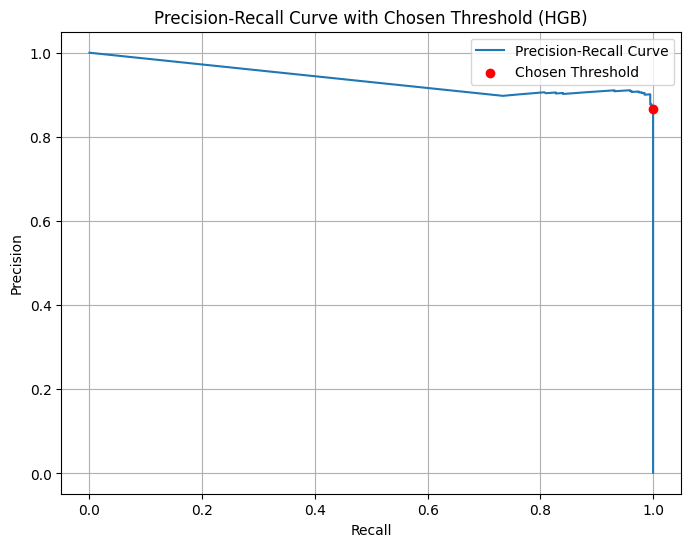

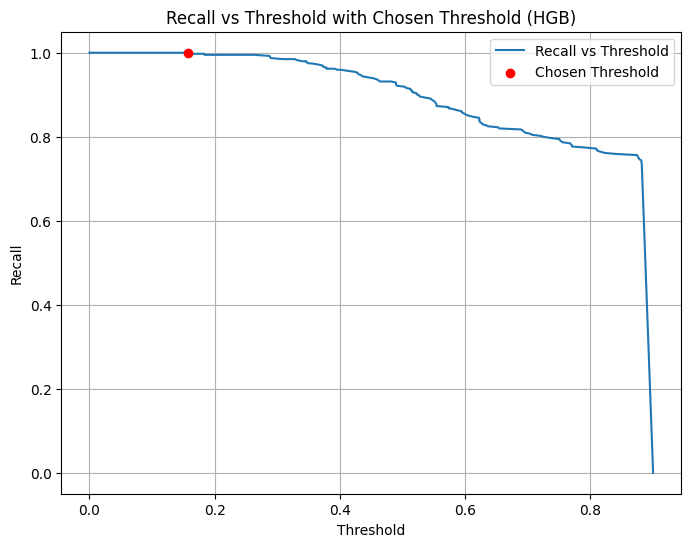

In [25]:
#PR curve for chosen threshold

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.scatter(metrics['recall'], metrics['precision'], color='red', label='Chosen Threshold', zorder=5)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Chosen Threshold (HGB)")
plt.legend()
plt.grid()
plt.savefig(REPORTS_DIR / "pr_curve_chosen_threshold_hgb.png")
plt.show()

#Recall@FixedPRecision graph

plt.figure(figsize=(8, 6))
plt.plot(thr_ext, recall, label="Recall vs Threshold")
plt.scatter(chosen_thr, metrics['recall'], color='red', label='Chosen Threshold', zorder=5)
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold with Chosen Threshold (HGB)")
plt.legend()
plt.grid()
plt.savefig(REPORTS_DIR / "recall_vs_threshold_chosen_threshold_hgb.png")



In [29]:
import numpy as np
from scipy.stats import uniform, randint

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold

# --- 1) Param search space (HGB) ---
param_distributions = {
    "classifier__learning_rate": uniform(0.01, 0.19),
    "classifier__max_leaf_nodes": randint(15, 50),
    "classifier__min_samples_leaf": randint(5, 30),
    "classifier__max_iter": randint(100, 600),
}

# --- 2) Custom scorer: maximize recall (TPR) subject to FPR <= max_fpr ---
def recall_at_max_fpr(y_true, y_score, max_fpr=0.001, **kwargs):
    """
    y_score is expected to be probability of positive class (fraud).
    **kwargs is required because newer sklearn may pass extra kwargs (e.g., needs_proba).
    """
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ok = np.where(fpr <= max_fpr)[0]
    return float(np.max(tpr[ok])) if ok.size else 0.0

recall_fpr_0p1_scorer = make_scorer(
    recall_at_max_fpr,
    needs_proba=True,   # tells sklearn to pass predict_proba output
    max_fpr=0.001       # passed to recall_at_max_fpr as kwarg
)

# --- 3) Multi-metric scoring; refit by your KPI ---
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall_fpr_0p1": recall_fpr_0p1_scorer,
}

# If you haven't defined skf yet, define it like this:
# (shuffle is important for randomized search reproducibility)
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=scoring,
    refit="recall_fpr_0p1",
    n_jobs=-1,
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=2,
    error_score="raise",  # fail fast if something else breaks
)

# --- 4) class imbalance handling for HGB via sample_weight ---
# If you want "balanced" behavior for HistGradientBoostingClassifier, use sample weights:
USE_SAMPLE_WEIGHT = True  # set True if you want it
W_POS = 200              # try 50, 100, 200

if USE_SAMPLE_WEIGHT:
    sample_weight = np.where(y_train == 1, W_POS, 1.0)
    random_search.fit(X_train, y_train, classifier__sample_weight=sample_weight)
else:
    random_search.fit(X_train, y_train)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, classifier__min_samples_leaf=27; total time=   4.0s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, classifier__min_samples_leaf=27; total time=   4.3s
[CV] END classifier__learning_rate=0.08116262258099886, classifier__max_iter=448, classifier__max_leaf_nodes=29, classifier__min_samples_leaf=15; total time=   4.7s
[CV] END classifier__learning_rate=0.08116262258099886, classifier__max_iter=448, classifier__max_leaf_nodes=29, classifier__min_samples_leaf=15; total time=   4.6s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, classifier__min_samples_leaf=27; total time=   4.5s
[CV] END classifier__learning_rate=0.15814129005182617, classifier__max_iter=120, classifier__max_leaf_nodes=33, 

In [30]:
import json
# Set the best parameters for the model
best_model = random_search.best_estimator_

best_model.fit(X_train, y_train)

oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
chosen_thr, strategy, metrics = choose_threshold_max_recall_at_fpr(
    y_true=y_train,
    proba=oof_proba,
    max_fpr=0.001
)

print(f"Chosen threshold after hyperparameter tuning: {chosen_thr}, strategy: {strategy}")
print("Metrics at chosen threshold after hyperparameter tuning:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {round(metric_value, 4)}")

best_params = random_search.best_params_

print("Best Parameters:", best_params)

with open(REPORTS_DIR / "best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)


Chosen threshold after hyperparameter tuning: 0.009550051827792954, strategy: Max recall with FPR≤0.0010
Metrics at chosen threshold after hyperparameter tuning:
threshold: 0.0096
fpr: 0.001
recall: 0.8223
precision: 0.5912
f1: 0.6879
Best Parameters: {'classifier__learning_rate': np.float64(0.18850479889719593), 'classifier__max_iter': 545, 'classifier__max_leaf_nodes': 28, 'classifier__min_samples_leaf': 20}
